# Visão Geral

Este notebook testa a acurácia de um modelo LLM ([Snowflake/snowflake-arctic-embed-l-v2.0](https://huggingface.co/Snowflake/snowflake-arctic-embed-l-v2.0)) nas seguinte tarefas:

* Tarefa 1: Identificar se um item extraído do PNCP é ou não um medicamento através de sua descrição textual.
* Tarefa 2: Identificar o código BR correto do item.

##### Metodologia

Os medicamentos a serem identificados vêm de registros de compras publicadas no PNCP (Portal Nacional de Contratações Públicas).

A descrição do medicamento a ser identificado é comparada às descrições de medicamentos de um catálago de referência ([CATMAT](https://www.gov.br/compras/pt-br/sistemas/conheca-o-compras/catalogo)) e, dentre os medicamentos catalogados, é escolhido aquele cuja descrição mais se aproxima do medicamento alvo.

O modelo LLM é um transformador que gera embeddings para cada descrição, tanto para as do PNCP quanto para as do catálogo. Após essa etapa, os embeddings são comparados utilizando a similaridade de cosseno e o medicamento do catálogo que apresentar a maior similaridade com o medicamento alvo é escolhido como identificador do medicamento alvo. A seção <span style="color:teal;">Exemplo com 1 medicamento</span>, ao final do notebook, fornece uma visão geral de como o algoritmo funciona. 

* Se o medicamento do catálogo mais similar ao item alvo, ainda assim, apresentar uma similaridade abaixo de um limite definido, considera-se que o item alvo não é um medicamento.

Para testar a acurácia do modelo, foi construído um conjunto de dados de teste com 1k observações rotuladas manualmente. 

##### Conclusão
Dos 1000 itens rotulados manualmente (dados de teste):
* 642 foram rotulados como medicamento
* 175 foram rotulados como não medicamento
* 183 foram rotulados como "incerteza" (estes foram descartados)


---- 

**Tarefa 1: Identificar se um item é ou não um medicamento (acurácia de 98%)**
* Dos 817 itens rotulados, o modulo acertou o rótulo em 797 casos (98%), considerando um limite de similaridade de 0.5 para diferenciar se é ou não um medicamento.

**Tarefa 2: Identificar o código BR correto (acurácia de 86%)**
* Dos 642 itens rotulados com um código BR, o modelo identificou corretamente o código BR em 551 casos (86%).

-------

In [7]:
import pyreadr  # Lê arquivos .rds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score

from transformers import pipeline
from sentence_transformers import SentenceTransformer

# Pré-processamento dos dados

* Seleciona somente as colunas que serão úteis.
* Transforma os textos para caixa baixa (letras minúsculas).

In [62]:
# Lê os arquivos de dados (rds)
medicamentos_rds = pyreadr.read_r("../../../data/pncp/medicamentos.rds")
catmat_rds = pyreadr.read_r("../../../data/catmat/catmat-para-python.rds")  # utilize o catmat-para-python.rds (sem colunas aninhadas)

# Extrai o dataframe
medicamentos_df = medicamentos_rds[None]
catmat_df = catmat_rds[None]

# Verifica número de registros
print(f'Número de medicamentos (PNCP): {len(medicamentos_df)}')
print(f'Número de medicamentos (CATMAT): {len(catmat_df)}')

Número de medicamentos (PNCP): 144967
Número de medicamentos (CATMAT): 5771


In [63]:
# Visualiza o dataframe de medicamentos
medicamentos_df.head(5)

,endpoint,numeroItem,descricao,materialOuServico,materialOuServicoNome,valorUnitarioEstimado,valorTotal,quantidade,unidadeMedida,orcamentoSigiloso,...,temResultado,imagem,aplicabilidadeMargemPreferenciaNormal,aplicabilidadeMargemPreferenciaAdicional,percentualMargemPreferenciaNormal,percentualMargemPreferenciaAdicional,ncmNbsCodigo,ncmNbsDescricao,clean_descricao,codigo_pdm
0,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,8.0,Cloreto de potássio,M,Material,283.24,283.24,1.0,Quilograma,False,...,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,cloreto de potassio,5116
1,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,9.0,Acetato De Cálcio,M,Material,845.37,845.37,1.0,Quilograma,False,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,acetato de calcio,1733
2,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,Álcool Etílico,M,Material,20.12,1207.20,60.0,Frasco 1000 ML,False,...,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,alcool etilico,2259
3,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,2.0,Álcool Etílico,M,Material,10.30,370.80,36.0,Frasco 1000 ML,False,...,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,alcool etilico,2259
4,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,Contraste Radiológico,M,Material,53.32,56999.08,1069.0,Frasco 50 ML,False,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,contraste radiologico,5804


In [64]:
# Visualiza o dataframe do CATMAT
catmat_df.head(3)

,codigo_grupo,nome_grupo,codigo_classe,nome_classe,codigo_pdm,nome_pdm,codigo_br,nome_item,desc_item,item_suspenso,item_ativo,desc_item_ativo,item_sustentavel,desc_item_sustentavel
0,65,"EQUIPAMENTOS E ARTIGOS PARA USO MÉDICO, DENTÁR...",6505,DROGAS E MEDICAMENTOS,14597,Petrolato,233632,"Petrolato, Aspecto Físico:Líquido, Tipo:Laxati...","233632 - Petrolato, Aspecto Físico:Líquido, Ti...",False,True,Ativo,False,NÃO SUSTENTAVEL
1,65,"EQUIPAMENTOS E ARTIGOS PARA USO MÉDICO, DENTÁR...",6505,DROGAS E MEDICAMENTOS,8325,Imunoglobulina Humana,260160,"Imunoglobulina Humana, Tipo:Hiper Imuni Para H...","260160 - Imunoglobulina Humana, Tipo:Hiper Imu...",False,True,Ativo,False,NÃO SUSTENTAVEL
2,65,"EQUIPAMENTOS E ARTIGOS PARA USO MÉDICO, DENTÁR...",6505,DROGAS E MEDICAMENTOS,3924,Fenoterol Bromidrato,266532,"Fenoterol Bromidrato, Dosagem:0,2mg / Dose, Ap...","266532 - Fenoterol Bromidrato, Dosagem:0,2mg /...",False,True,Ativo,False,NÃO SUSTENTAVEL


### Medicamentos PNCP

In [65]:
# Seleciona colunas úteis 
medicamentos_df = medicamentos_df[['endpoint', 'numeroItem', 'codigo_pdm', 'descricao', 'unidadeMedida']].copy()

# Deixa a descricao e unidadeMedida em minusculo
medicamentos_df['descricao'] = medicamentos_df['descricao'].astype(str).str.lower()
medicamentos_df['unidadeMedida'] = medicamentos_df['unidadeMedida'].astype(str).str.lower()

medicamentos_df.head(5)

,endpoint,numeroItem,codigo_pdm,descricao,unidadeMedida
0,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,8.0,5116,cloreto de potássio,quilograma
1,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,9.0,1733,acetato de cálcio,quilograma
2,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,2259,álcool etílico,frasco 1000 ml
3,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,2.0,2259,álcool etílico,frasco 1000 ml
4,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,5804,contraste radiológico,frasco 50 ml


### Catálogo de materiais (CATMAT)

In [66]:
# Seleciona colunas úteis 
catmat_df = catmat_df[['codigo_pdm', 'codigo_br', 'nome_item']].copy()

# Deixa a descricao em minusculo
catmat_df['nome_item'] = catmat_df['nome_item'].astype(str).str.lower()

# Define o código PDM como índice
catmat_df.set_index('codigo_pdm', inplace=True)

catmat_df.head(5)

,codigo_br,nome_item
codigo_pdm,,
14597,233632,"petrolato, aspecto físico:líquido, tipo:laxati..."
8325,260160,"imunoglobulina humana, tipo:hiper imuni para h..."
3924,266532,"fenoterol bromidrato, dosagem:0,2mg / dose, ap..."
17667,266665,"arteméter, dosagem:80 mg/ml, apresentação:solu..."
3946,266699,"budesonida, apresentação:aerossol bucal, conce..."


# De texto para embeddings

<span style="color: orange"> Pular esta etapa de vetorização caso os embeddings já tenham sido gerados (ver diretório *outputs*).</span>

* Carrega o modelo previamente treinado.
* Gera os embeddings das descrições de medicamentos do PNCP (consultas) e do CATMAT (documentos).
* Compara os embeddings e seleciona o documento mais similar a cada consulta.
* Salva os embeddings já computados e o medicamento mais similar.

In [172]:
# Carrega o modelo
# Mais informações em: https://huggingface.co/Snowflake/snowflake-arctic-embed-l-v2.0
model_name = 'Snowflake/snowflake-arctic-embed-l-v2.0'
model = SentenceTransformer(model_name)

In [173]:
# Define as consultas e os documentos
consultas = medicamentos_df['descricao']
documentos = catmat_df['nome_item']

# Computa os embeddings: use `prompt_name="query"` para codificar (encode) as consultas
embeddings_consultas = model.encode(consultas, prompt_name="query") 
embeddings_documentos = model.encode(documentos)

# Adiciona os embeddings como uma coluna no dataframe
medicamentos_df['embedding'] = list(embeddings_consultas)
catmat_df['embedding'] = list(embeddings_documentos)

In [174]:
def mais_similar(medicamento):
    """
    Retorna o medicamento do CATMAT cujo embedding da descrição é o mais similar ao embedding
    da descrição do medicamento passado como argumento para a função.

    Parâmetros:
    ----------
    medicamento : object <class 'pandas.core.series.Series'>
        Uma série pandas (possivelmente uma linha de um dataframe) que deve conter as dimensões 
        'embedding' (vetor de números) e 'codigo_pdm'.

    Retorna:
    -------
    str, float
        Uma tupla com o código BR do item do CATMAT mais similar à consulta e a similaridade (do cosseno)
    """

    # embedding da descrição + unidadeMedida do item no PNCP
    consulta = medicamento['embedding']
    
    # Código PDM do item no PNCP. O código foi definido por um filtro automático. 
    # Ver https://github.com/Transparencia-Brasil/pncp-analises/blob/main/tasks/pncp-data-quality/src/filtra-medicamentos.R
    codigoPDM = medicamento['codigo_pdm']

    # Seleciona os itens do CATMAT que possuem o mesmo PDM do item do PNCP
    itens_pdm = catmat_df.loc[[str(codigoPDM)]] # Use double brackets para forçar o resultado a ser um dataframe
    
    # Computa a similaridade entre os embeddings da descrição do CATMAT e o embedding do item do PNCP
    similaridades = model.similarity(consulta, itens_pdm['embedding'])
    itens_pdm['similaridade'] = similaridades.numpy()[0]
    
    # Define o índice como o codigo_br para agilizar a próxima operação
    itens_pdm.set_index('codigo_br', inplace=True)
    
    # Identifica o código BR do item do CATMAT com maior similaridade
    medicamento_mais_similar = itens_pdm.loc[itens_pdm['similaridade'].idxmax()].name
    similaridade = itens_pdm.loc[medicamento_mais_similar].similaridade
    
    return medicamento_mais_similar, similaridade

In [175]:
# Encontra o medicamento do CATMAT mais similar a cada item do PNCP
medicamentos_df[['mais_similar', 'similaridade']] = medicamentos_df.apply(mais_similar, axis=1, result_type='expand')

# Junta os medicamentos do PNCP com os do CATMAT para poder comparar as descrições do PNCP e do CATMAT
medicamentos_df = pd.merge(medicamentos_df, catmat_df[['codigo_br', 'nome_item']], left_on='mais_similar', right_on='codigo_br', how='left')

c:\Users\luiz_\AppData\Local\Programs\Python\Python311\Lib\site-packages\sentence_transformers\util.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  a = torch.tensor(a)


In [176]:
# salva os dados em formato .csv
medicamentos_df.to_csv("../outputs/medicamentos-embeddings.csv", index=False)
catmat_df.to_csv("../outputs/catmat-embeddings.csv", index=False)

# Avaliação

* Compara a rotulagem automática feita com os embeddings com um conjunto de dados rotulados manualmente.

### Dados rotulados

In [2]:
# Lê o arquivo de dados
rotulos_df  = pd.read_csv("../inputs/medicamentos-rotulados.csv")

# Renomeia as colunas, padronizando-as
rotulos_df.columns = ['endpoint', 'numero_item', 'codigo_pdm', 'descricao', 'unidade_medida', 'rotulo', 'codigo_br', 'medicamento', 'observacao']

# Seleciona as colunas que serão úteis
rotulos_df = rotulos_df[['endpoint', 'numero_item', 'descricao', 'rotulo', 'codigo_br', 'medicamento']]

# Converte "Sim" para True e "Não" para False na coluna "medicamento"
rotulos_df["medicamento"] = rotulos_df["medicamento"].map({"Sim": True, "Não": False})

# Remove os rotulos incertos (medicamento == nan)
rotulos_df = rotulos_df.dropna(subset=["medicamento"])

# Converte a coluna para booleano
rotulos_df['medicamento'] = rotulos_df['medicamento'].astype(bool)

# Visualiza os dados
rotulos_df.head(5)

,endpoint,numero_item,descricao,rotulo,codigo_br,medicamento
0,https://pncp.gov.br/api/pncp/v1/orgaos/0351710...,5629,Exame - Tipo: imunoensaio; Espécie: quantitati...,NaN,NaN,False
1,https://pncp.gov.br/api/pncp/v1/orgaos/0877826...,7,AMIODARONA 50 mg/mL solução injetável intraven...,"PDM: 2420 - Amiodarona, Dosagem:50mg/Ml, Indic...",271710.0,True
2,https://pncp.gov.br/api/pncp/v1/orgaos/0795448...,7,"METOCLOPRAMIDA (CLORIDRATO), 5MG/ML, SOLUCAO I...","PDM: 9702 - Metoclopramida Cloridrato, Dosagem...",267310.0,True
3,https://pncp.gov.br/api/pncp/v1/orgaos/0117964...,6,"CLORETO DE SÓDIO 17,55% AMPOLA 10 ML","PDM: 5118 - Cloreto De Sódio, Concentraçao:17,...",412432.0,True
4,https://pncp.gov.br/api/pncp/v1/orgaos/1142091...,1,ACEBROFILINA 10 MGML 120 ML SUSP. FRASCO ...,"PDM: 14456 - Acebrofilina, Concentração:10 MG/...",448839.0,True


### Dados de teste

In [3]:
# Lê o arquivo de dados
teste_df = pd.read_csv("../outputs/medicamentos-embeddings.csv")

# Seleciona as colunas que serão úteis
teste_df = teste_df[['endpoint', 'numeroItem', 'codigo_pdm', 'mais_similar', 'similaridade', 'nome_item']].rename(columns={"numeroItem": "numero_item"})

# Seleciona somente os itens que foram rotulado
teste_df = teste_df.merge(rotulos_df, on = ['endpoint', 'numero_item'], how = 'inner')

# Visualiza os dados
teste_df.head(5)

,endpoint,numero_item,codigo_pdm,mais_similar,similaridade,nome_item,descricao,rotulo,codigo_br,medicamento
0,https://pncp.gov.br/api/pncp/v1/orgaos/1512643...,1.0,1820,278283,0.580957,"acetazolamida, dosagem:250 mg",Acetazolamida,"PDM: 1820 - Acetazolamida, Dosagem:250 MG",278283.0,True
1,https://pncp.gov.br/api/pncp/v1/orgaos/0795448...,7.0,19449,437870,0.670350,"fumarato de dimetila, concentração:240 mg, car...","FUMARATO, DIMETILA, CAPSULA DE LIBERACAO RETAR...","PDM: 19449 - Fumarato De Dimetila, Concentraçã...",437870.0,True
2,https://pncp.gov.br/api/pncp/v1/orgaos/0795448...,6.0,16486,357788,0.797610,"mepivacaína cloridrato, concentração:3%, forma...","MEPIVACAINA CLORIDRATO, 3% 30MG/ML, SOLUCAO I...","PDM: 16486 - Mepivacaína Cloridrato, Concentra...",357788.0,True
3,https://pncp.gov.br/api/pncp/v1/orgaos/0795448...,3.0,5083,272901,0.688218,"clobazam, dosagem:10 mg","CLOBAZAM, 10MG, COMPRIMIDO, UNIDADE 1.0 COMPRI...","PDM: 5083 - Clobazam, Dosagem:10 MG",272901.0,True
4,https://pncp.gov.br/api/pncp/v1/orgaos/0795448...,4.0,8254,270621,0.819041,"escopolamina butilbrometo, apresentação:associ...","ESCOPOLAMINA BUTILBROMETO + DIPIRONA, 4MG/ML +...","PDM: 8254 - Escopolamina Butilbrometo, Apresen...",270621.0,True


### Métricas

#### Acurácia ao prever se é ou não um medicamento

O item do PNCP será identificado como medicamento caso a similaridade com o item mais similar do CATMAT atinja um valor mínimo definido.    

Diferentes valores mínimos são testados como threshold e a acurácia de cada um é medida.

In [4]:
# Quantos itens estão rotulados como medicamento (True) e não medicamento (False)?
rotulos_df['medicamento'].value_counts()

True     1287
False     392
Name: medicamento, dtype: int64

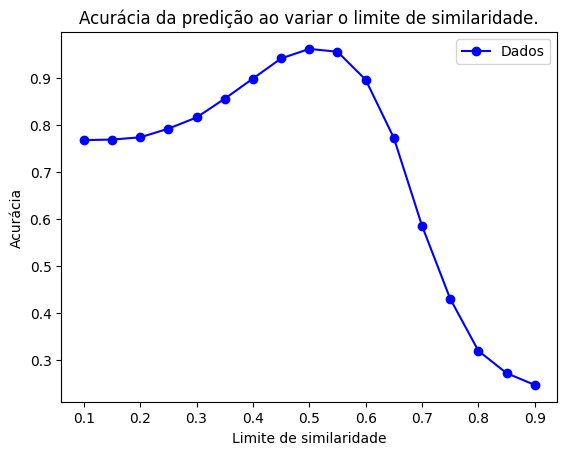

In [8]:
resultados_acuracia = {}

for limite in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    teste_df['medicamento_pred'] = teste_df['similaridade'] >= limite
    y_true = teste_df['medicamento']
    y_pred = teste_df['medicamento_pred']

    resultados_acuracia[limite] = accuracy_score(y_true, y_pred)

# Visualiza os resultados
# Extrai chaves e valores
eixo_x = list(resultados_acuracia.keys())
eixo_y = list(resultados_acuracia.values())

# Criar o gráfico de linha
plt.plot(eixo_x, eixo_y, marker='o', linestyle='-', color='b', label='Dados')

# Adiciona rótulos e título
plt.title("Acurácia da predição ao variar o limite de similaridade.")
plt.xlabel("Limite de similaridade")
plt.ylabel("Acurácia")
plt.legend()

# Mostra o gráfico
plt.show()

In [9]:
# identifica o limite com a maior acurácia
limite = max(resultados_acuracia, key=resultados_acuracia.get)
print(f'O limite de maior acurácia é {limite}, com acurácia de {resultados_acuracia[limite]}')

O limite de maior acurácia é 0.5, com acurácia de 0.9612864800476474


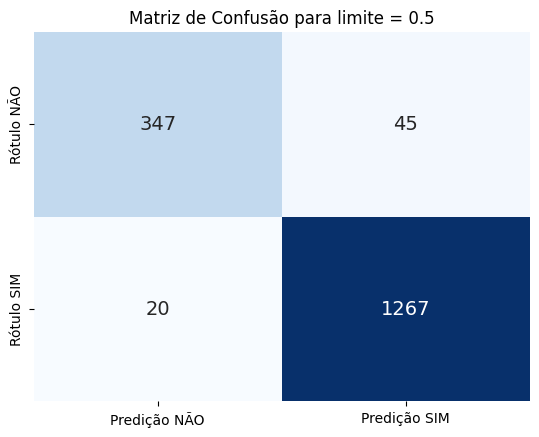

In [10]:
# Determina os itens que são medicamentos com o limite escolhido
teste_df['medicamento_pred'] = teste_df['similaridade'] >= limite

y_true = teste_df['medicamento']
y_pred = teste_df['medicamento_pred']

# Cria a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Cria um DataFrame para melhor visualização
cm_df = pd.DataFrame(cm, index=["Rótulo NÃO", "Rótulo SIM"], columns=["Predição NÃO", "Predição SIM"])

# Visualiza a matriz de confusão com heatmap
sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", cbar=False, annot_kws={'size': 14})
plt.title(f'Matriz de Confusão para limite = {limite}')
plt.show()

#### Acurácia ao prever o código BR do medicamento

Para os itens que foram identificados como medicamento, avaliamos se o modelo identificou o código BR correto.

In [11]:
# Filtra só os itens identificados como medicamento
teste_medicamentos_df = teste_df[teste_df['medicamento']].copy()

# Calcula se o modelo acertou ou não 
teste_medicamentos_df['acertou_pred'] = teste_medicamentos_df['mais_similar'] == teste_medicamentos_df['codigo_br']

# Computa a acurácia
acuracia = teste_medicamentos_df["acertou_pred"].sum() / len(teste_medicamentos_df)
print(f'O modelo acertou o código BR em {round(acuracia * 100, 2)}% dos itens.')

O modelo acertou o código BR em 85.24% dos itens.


# Exemplo com 1 medicamento

In [ ]:
# Carrega o modelo
# Mais informações em: https://huggingface.co/Snowflake/snowflake-arctic-embed-l-v2.0
model_name = 'Snowflake/snowflake-arctic-embed-l-v2.0'
model = SentenceTransformer(model_name)

In [ ]:
# Teste com o código PDM "15458" referente à "vacina"
vacina_df = medicamentos_df[medicamentos_df['codigo_pdm'] == "15458"]

# Define as consultas e os documentos
consultas = vacina_df['descricaoCompleta']
documentos = catmat_df['desc_item']

# Computa os embeddings: use `prompt_name="query"` para codificar (encode) as consultas
embeddings_consultas = model.encode(consultas, prompt_name="query") 
embeddings_documentos = model.encode(documentos)

# Adiciona os embeddings como uma coluna no dataframe
catmat_df['embedding'] = list(embeddings_documentos)
vacina_df['embedding'] = list(embeddings_consultas)

# Encontra o medicamento do CATMAT mais similar a cada item do dataframe vacina_df
vacina_df[['mais_similar', 'similaridade']] = vacina_df.apply(mais_similar, axis=1, result_type='expand')

# Junta com o dataframe de vacinas com o CATMAT para poder comparar as descrições do PNCP e do CATMAT
vacina_df = pd.merge(vacina_df, catmat_df[['codigo_br', 'desc_item']], left_on='mais_similar', right_on='codigo_br', how='left')

C:\Users\luiz_\AppData\Local\Temp\ipykernel_21804\2735864239.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vacina_df['embedding'] = list(embeddings_consultas)


In [208]:
# mostrar mais texto ao visualizar dataframes
pd.set_option('display.max_colwidth', None)  

# Mostra os itens menos similares encontrados pelo modelo
vacina_df.sort_values(by='similaridade').head(3)[['descricao', 'desc_item', 'codigo_br', 'similaridade']]

,descricao,desc_item,codigo_br,similaridade
703,"termometro digital com temperatura maxima e minima com sensor externo e alarme - este termômetro digital possui grande precisão de temperatura interna e externa, assim como as sua máximas e mínimas. visor em cristal líquido de fácil visualização. possui função de memorizar as leituras máximas e mínimas, internas e externas da temperatura, em um período de tempo e função alarme, permite escolher uma temperatura externa de limite máxima e/ou mínima. características: ideal para monitoramento da temperatura em freezers, caixa de vacina, salas de armazenamento e ambientes climatizados em geral medição precisa de temperatura interna e externa, assim como as suas máximas e mínimas função alarme. escolha uma temperatura externa de limite máximo e/ou mínimo, e quando atingir esta tal temperatura, o termômetro envia um alarme memoriza as leituras máximas e mínimas, internas e externas da temperatura, em um período de tempo visor de cristal líquido de fácil visualização possui sensor com pequena haste de metal para medir a temperatura externa pode ser usado na mesa ou parede (não inclui peças para fixação na parede) design moderno leve e compacto mede em °c e °f especificações técnicas temperatura ambiente (interna): - escala: -10+50°c - resolução: 0,1ºc - precisão: ± 1,0°c (entre 0°c e 50°c) / e ± 2,0°c (fora da faixa de 0°c à 50°c) temperatura externa: - escala: - 50+70°c - resolução: 0,1°c - precisão: ± 1,0°c (entre 0°c e 50°c) / e ± 2,0 °c (fora da faixa de 0°c à 50°c) cor: bra...","455973 - vacina, composição:extrato alergênico (até 5 antígenos), forma farmaceutica:injetável, característica adicional:liberação prolongada, características adicionais 1:especialmente manipulada",455973,0.180962
903,"servicos manutencao ar condicionado contratacao de empresa para servico de remocaode 07 condesadores que estao no telhado para olado externo, utilizacao de 70 metros de linha decobre, instalacao de 01 condicionador de ar de22.000 btus e trocar 03 aparelhos de ar condicio-nado.servico sera realizado na vigilancia epidemiolo-gica e sala de vacina da esf dr oswaldo damian.","613263 - vacina, composição:pneumocócica 15-valente, tipo:conjugada, forma farmaceutica:suspensão injetável",613263,0.210781
1204,"executar atividades dentro dos setores determinados pela chefia de enfermagem, aferir e controlar sinais vitais utilizando de equipamentos adequados, preparar pacientes para consultas e exames e outros procedimentos facilitando a sua realização executar curativos usando seus conhecimentos e prescrições médicas ou de enfermagem proporcionando alivio ao paciente, bem como facilitando a cicatrização de ferimentos, suturas e escoriações, auxiliar no preparo do material e instrumental para esterilização, bem como, na desinfecção de ambientes e equipamentos permitindo maior segurança aos procedimentos. administrar medicamentos via oral e o parenteral prestando informações aos clientes sobre possíveis reações, além de fazer vacina e fazer os devidos registros em formulários apropriados, realizar visita domiciliar elaborando após, o relatório, observar os cuidados universais em proteção individual, cumprir o código de ética da profissão e zelar por sua segurança e de terceiros bem como pela preservação e manutenção de materiais e equipamentos em seu ambiente de trabalho, realizar coleta de sangue para identificação de doenças; realizar testagem e acompanhamento de doenças de notificação compulsória; realizar visita domiciliar elaborando após o relatório, executar outras tarefas afins - hora","453048 - vacina, composição:febre amarela, tipo:atenuada, forma farmaceutica:pó liófilo p/ injetável + diluente",453048,0.224257


In [209]:
# Mostra os itens mais similares encontrados pelo modelo
vacina_df.sort_values(by='similaridade', ascending=False).head(3)[['descricao', 'desc_item', 'codigo_br', 'similaridade']]

,descricao,desc_item,codigo_br,similaridade
1551,"vacina composição: sarampo, caxumba, rubéula e varicela, tipo: atenuada, forma farmaceutica: pó liófilo p/ injetável + diluente","453090 - vacina, composição:sarampo, caxumba, rubéula e varicela, tipo:atenuada, forma farmaceutica:pó liófilo p/ injetável + diluente",453090,0.870807
1615,"vacina composição: sarampo, caxumba, rubéula e varicela, tipo: atenuada, forma farmaceutica: pó liófilo p/ injetável + diluente","453090 - vacina, composição:sarampo, caxumba, rubéula e varicela, tipo:atenuada, forma farmaceutica:pó liófilo p/ injetável + diluente",453090,0.869622
1614,"vacina composição: sarampo, caxumba, rubéula e varicela, tipo: atenuada, forma farmaceutica: pó liófilo p/ injetável + diluente","453090 - vacina, composição:sarampo, caxumba, rubéula e varicela, tipo:atenuada, forma farmaceutica:pó liófilo p/ injetável + diluente",453090,0.869622


In [ ]:
# Mostra os itens com similaridades entre 0.7 e 0.8
vacina_df.query('similaridade > 0.7 & similaridade < 0.8').head(3)[['descricao', 'desc_item', 'codigo_br', 'similaridade']]

,descricao,desc_item,codigo_br,similaridade
859,"vacina composição 1: covid-19 (coronavírus, sars-cov-2), forma farmacêutica 1: injetável","475096 - vacina, composição 1:covid-19 (coronavírus, sars-cov-2), forma farmacêutica 1:injetável",475096,0.790276
896,vacina papilomavírus humano 9-valente (recombinant vacina papilomavírus humano 9-valente (recombinante),"486446 - vacina, composição:hpv - papiloma vírus humano - 9 valente, tipo:recombinante, forma farmaceutica:suspensão injetável",486446,0.722965
978,"vacina composição: bcg, forma farmaceutica: pó liófilo p/ injetável + diluente","453044 - vacina, composição:bcg, forma farmaceutica:pó liófilo p/ injetável + diluente",453044,0.787939


In [ ]:
# Restaura o comportamento padrão de visualização de dataframes
pd.reset_option('display.max_colwidth')